# 01. Exploratory Data Analysis (EDA) - MovieLens 25M

Notebook này thực hiện khám phá tập dữ liệu MovieLens 25M để hiểu về hành vi của người dùng và đặc điểm của các bộ phim trước khi đưa vào hệ thống Big Data Pipeline.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Cấu hình hiển thị
%matplotlib inline
sns.set(style="whitegrid")

## 1. Load Dữ liệu

In [3]:
DATA_PATH = '../dataset/ml-25m/'
ratings = pd.read_csv(os.path.join(DATA_PATH, 'ratings.csv'))
movies = pd.read_csv(os.path.join(DATA_PATH, 'movies.csv'))

print(f"Ratings shape: {ratings.shape}")
print(f"Movies shape: {movies.shape}")

Ratings shape: (25000095, 4)
Movies shape: (62423, 3)


## 2. Thống kê tổng quan

In [4]:
n_ratings = len(ratings)
n_movies = ratings['movieId'].nunique()
n_users = ratings['userId'].nunique()

print(f"Số lượng đánh giá: {n_ratings}")
print(f"Số lượng phim có đánh giá: {n_movies}")
print(f"Số lượng người dùng: {n_users}")
print(f"Trung bình số đánh giá mỗi người dùng: {round(n_ratings/n_users, 2)}")

Số lượng đánh giá: 25000095
Số lượng phim có đánh giá: 59047
Số lượng người dùng: 162541
Trung bình số đánh giá mỗi người dùng: 153.81


## 3. Phân phối điểm đánh giá (Rating Distribution)

C:\Users\tanba\AppData\Local\Temp\ipykernel_10924\3626401932.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='viridis')


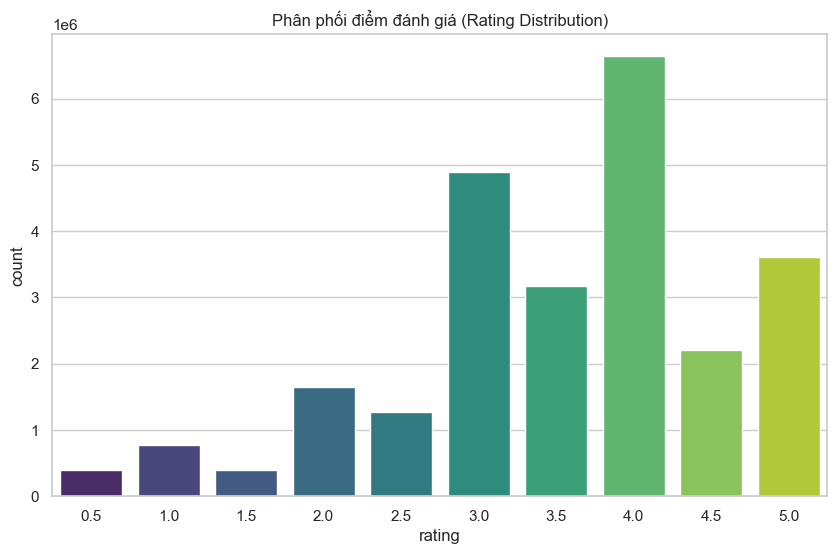

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=ratings, palette='viridis')
plt.title("Phân phối điểm đánh giá (Rating Distribution)")
plt.show()

## 4. Top 10 bộ phim phổ biến nhất

In [6]:
movie_ratings_count = ratings.groupby('movieId').size().sort_values(ascending=False)
top_10_movies = movie_ratings_count.head(10).reset_index()
top_10_movies.columns = ['movieId', 'count']

# Merge với tên phim
top_10_titles = pd.merge(top_10_movies, movies, on='movieId')
top_10_titles[['title', 'count']]

,title,count
0,Forrest Gump (1994),81491
1,"Shawshank Redemption, The (1994)",81482
2,Pulp Fiction (1994),79672
3,"Silence of the Lambs, The (1991)",74127
4,"Matrix, The (1999)",72674
5,Star Wars: Episode IV - A New Hope (1977),68717
6,Jurassic Park (1993),64144
7,Schindler's List (1993),60411
8,Braveheart (1995),59184
9,Fight Club (1999),58773


## 5. Phân tích Thể loại (Genres)

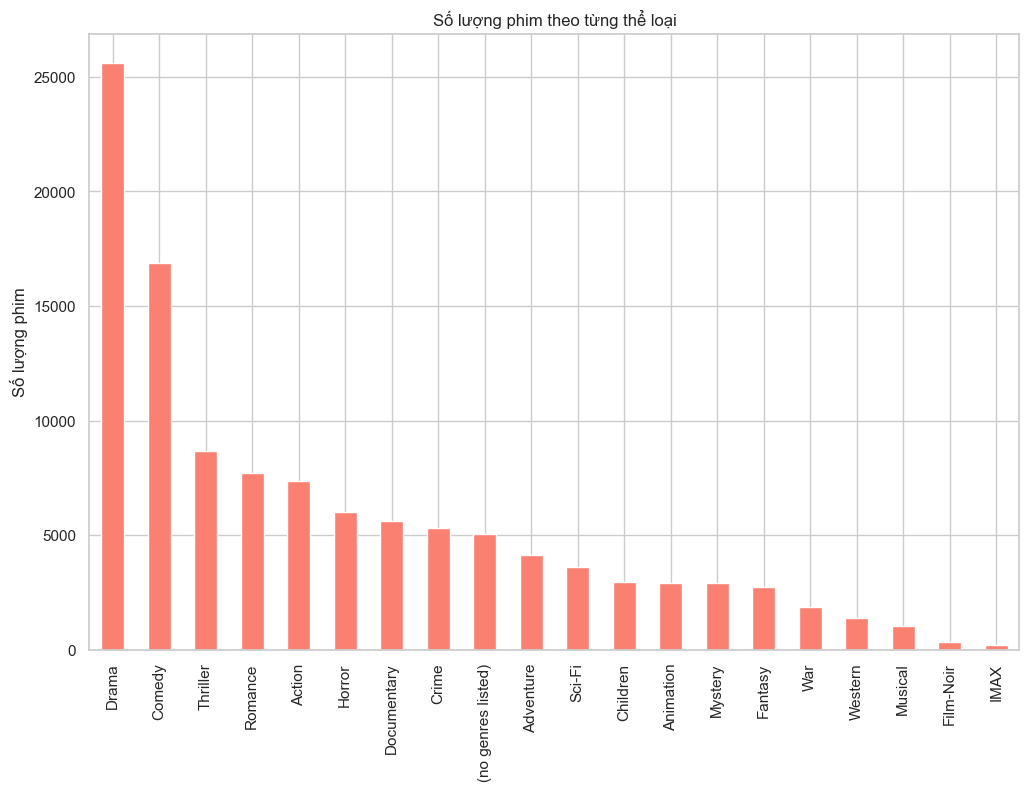

In [7]:
genres_count = movies['genres'].str.split('|', expand=True).stack().value_counts()
plt.figure(figsize=(12, 8))
genres_count.plot(kind='bar', color='salmon')
plt.title("Số lượng phim theo từng thể loại")
plt.ylabel("Số lượng phim")
plt.show()